---
title: Sensitivity Testing
date: 09/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

The spatiotemporal DBSCAN procedure we use to create our AR catalog involves several hyperparameters. The final choices of these hyperparameters were largely motivated by our physical understanding of ARs in Antarctica (background domain knowledge), and verified 'by-eye' by tracking down known ARs from numerous case studies in the Antarctic AR literature and checking that their landfalling time, duration, etc. matches what we found in our catalog. However, there are several perturbations to these parameters that we could have made, and this notebook documents the sensitivity of various AR metrics to these perturbations, conveying the overall importance of getting certain hyperparameters "right."

:::{caution}
If you are running this notebook yourself, ensure you are able to load up to 8GB of objects in memory. If using CryoCloud, we recommend choosing a server with at least 10GB of memory.
:::

## Hyperparameters Overview

In the clustering algorithm, there are several hyperparameters:
+ `epsilon_space`: spatial neighborhood, given in fractions of synoptic scale (1000 km)
+ `epsilon_time`: time neighborhood, given in hours
+ `minpts`: the minimum number of neighboring points to be considered a core point
+ `n_rep_pts`: the number of representative points to sample from each cluster at each time step

In the below sections, we explore the sensitivity of the clustering results to each of these hyperparameters. In our explorations and ground-truthing exercises, we found that an ideal set of hyperparameters are `epsilon_space: 0.5`, `epsilon_time: 12`, `minpts: 5`, and `n_rep_pts: 10`. We will perturb these hyperparameters individually and explore how they affect clustering results relative to this base setting.

In [2]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
import seaborn as sns
from huggingface_hub import login, hf_hub_download # used to download catalogs with perturbed hyperparams

from artools.display_utils import display_catalog

First, we define the following helper function, which we will use to process and compute counts of landfalling ARs in catalogs constructed with perturbed values of a hyperparameter of interest. We also define a helper function that downloads the relevant catalog from the HuggingFace repository and loads it into a pandas DataFrame.

In [3]:
def process_cts(dictionary):
    '''
    A simple helper function that takes in a dictionary mapping hyperparameter variations
        (deviations from the default/official set) to the respective catalog in pd.DataFrame
        format, and computes landfalling storm counts.
    '''

    res_dict = {}
    total_cts = []
    landfall_cts = []
    for param, df in dictionary.items():
        landfalling = df[df.is_landfalling]
        total_cts.append(df.shape[0])
        landfall_cts.append(landfalling.shape[0])

    res_dict = {'total': total_cts, 'landfalling': landfall_cts}
    res_df = pd.DataFrame(res_dict, index=list(dictionary.keys()))

    return res_df

def load_catalog(fname):
    '''
    Function that downloads a catalog from the HuggingFace repository and loads
        it up into a pandas DataFrame
    '''

    file_path = hf_hub_download(
        repo_id='butlerj/antarctic_AR_catalogs',
        filename=fname,
        repo_type='dataset')

    catalog = pd.read_hdf(file_path)

    return catalog
    

:::{attention}
The HuggingFace repository with the catalogs is private at the moment. So, to fully run through this notebook, you will need to be added to the repository with the requisite permissions and log in to HuggingFace using the following cell. When the project is finished, the catalogs will be made fully available for public access.
:::

In [4]:
login()

We first load up the catalog with the official set of parameters. In the rest of the notebook, we go through each hyperparameter and vary that particular hyperparameter relative to the original setting. So, each hyperparameter is only varied individually, not together.

In [5]:
baseline_df = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')

## `epsilon_space` perturbations

We first perturb the $\epsilon_{space}$ parameter. This parameter is represented as fractions of synoptic scale, or fractions of $1000$ km.

In [6]:
# constructing dictionaries to organize results
space_dict = {}
space_dict['0.5'] = baseline_df
space_dict['0.25'] = load_catalog('epsspace0.25_epstime12_minpts5_nreppts10_seed12345.h5')
space_dict['0.75'] = load_catalog('epsspace0.75_epstime12_minpts5_nreppts10_seed12345.h5')
space_dict['1.0'] = load_catalog('epsspace1.0_epstime12_minpts5_nreppts10_seed12345.h5')

In [7]:
res_df = process_cts(space_dict)
res_df

,total,landfalling
0.5,8714,3179
0.25,11660,3630
0.75,8121,3082
1.0,7710,3031


To better assess the sensitivity of storm counts to hyperparameter perturbations, relative to the storm counts of the official configuration, we also compute the percent difference between storm counts of catalogs with the perturbed hyperparameters and the official catalog.

In [8]:
# percent difference, expressed as a percentage of the total number of storms in baseline configuration
space_percents = (res_df - res_df.loc['0.5'])/res_df.loc['0.5']
space_percents

,total,landfalling
0.5,0.000000,0.000000
0.25,0.338077,0.141869
0.75,-0.068051,-0.030513
1.0,-0.115217,-0.046556


We also visualize the percent differences.

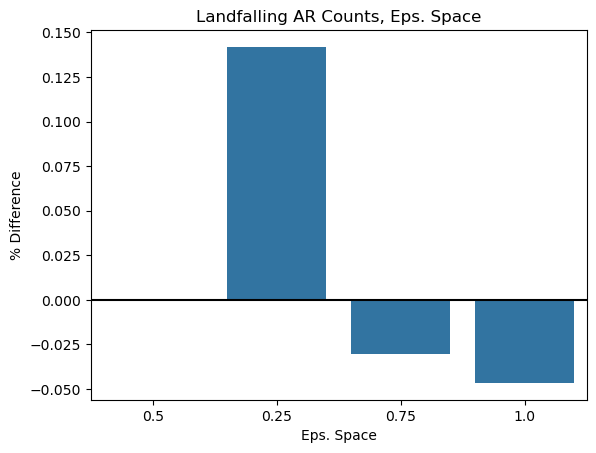

In [9]:
sns.barplot(data=space_percents, x=space_percents.index, y='landfalling', errorbar=None);
plt.axhline(y=0, linestyle='-', color='black')
plt.title('Landfalling AR Counts, Eps. Space')
plt.xlabel('Eps. Space')
plt.ylabel('% Difference');

**Takeaway:** Higher spatial epsilons lead to less ARs, which makes sense as ARs that are close to one another in the same time step are more likely to be grouped together. However, once you are at half a synoptic scale (`0.5`), the percent difference in the number of landfalling ARs is relatively small. It also appears that the total number of ARs is more sensitive to these perturbations. `0.25` has substantially more landfalling ARs, but this is much too small as groups of AR points within this small distance (250 km) are likely part of the same system.

## `epsilon_time` perturbations

We next move on to perturbing the $\epsilon_{time}$ parameter. This parameter is expressed in units of hours, and represents how far into the future and past we will look for candidate neighboring points in our clustering algorithm.

In [10]:
# constructing dictionaries to organize results
time_dict = {}
time_dict['9'] = load_catalog('epsspace0.5_epstime9.0_minpts5_nreppts10_seed12345.h5')
time_dict['12'] = baseline_df
time_dict['15'] = load_catalog('epsspace0.5_epstime15.0_minpts5_nreppts10_seed12345.h5')
time_dict['18'] = load_catalog('epsspace0.5_epstime18.0_minpts5_nreppts10_seed12345.h5')
time_dict['21'] = load_catalog('epsspace0.5_epstime21.0_minpts5_nreppts10_seed12345.h5')
time_dict['24'] = load_catalog('epsspace0.5_epstime24.0_minpts5_nreppts10_seed12345.h5')

epsspace0.5_epstime15.0_minpts5_nreppts1(…):   0%|          | 0.00/325M [00:00<?, ?B/s]

epsspace0.5_epstime18.0_minpts5_nreppts1(…):   0%|          | 0.00/332M [00:00<?, ?B/s]

epsspace0.5_epstime21.0_minpts5_nreppts1(…):   0%|          | 0.00/338M [00:00<?, ?B/s]

epsspace0.5_epstime24.0_minpts5_nreppts1(…):   0%|          | 0.00/343M [00:00<?, ?B/s]

In [11]:
res_df = process_cts(time_dict)
res_df

,total,landfalling
9,9263,3307
12,8714,3179
15,8356,3077
18,8063,2997
21,7820,2919
24,7610,2865


In [12]:
# percent difference, expressed as a percentage of the total number of storms in baseline configuration
time_percents = (res_df - res_df.loc['12'])/res_df.loc['12']
time_percents

,total,landfalling
9,0.063002,0.040264
12,0.000000,0.000000
15,-0.041083,-0.032086
18,-0.074707,-0.057251
21,-0.102594,-0.081787
24,-0.126693,-0.098773


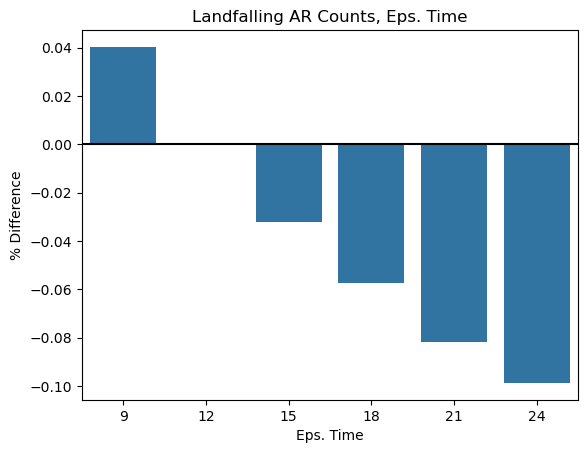

In [13]:
sns.barplot(data=time_percents, x=time_percents.index, y='landfalling', errorbar=None);
plt.axhline(y=0, linestyle='-', color='black')
plt.title('Landfalling AR Counts, Eps. Time')
plt.xlabel('Eps. Time')
plt.ylabel('% Difference');

**Takeaway:** This parameter seems to be consistently impacting the number of landfalling and total numbers of ARs. As before, it seems the total number of ARs is more sensitive to these perturbations. When searching for neighboring points, this parameter represents the time window where we can consider other points to potentially be a part of this same cluster. Anything higher than 18 hours seems too long, since if an AR disappears for 18 hours, it is likely another system. A well-accepted threshold for stitching ARs temporally is 12 hours, as employed in [Maclennan et al. (2023)](https://doi.org/10.5194/tc-17-865-2023) and the definition of [cloud-mass meridional transport events](https://amrdc.ssec.wisc.edu/projects/cmmt).

## `minpts` perturbations

We also vary `minpts`, or the minimum number of points that must be in a neighborhood of another point for that point to be considered a core point, and potentially instantiate its own cluster if it isn't already part of one.

In [14]:
minpts_dict = {}
minpts_dict['3'] = load_catalog('epsspace0.5_epstime12_minpts3_nreppts10_seed12345.h5')
minpts_dict['5'] = baseline_df
minpts_dict['8'] = load_catalog('epsspace0.5_epstime12_minpts8_nreppts10_seed12345.h5')
minpts_dict['10'] = load_catalog('epsspace0.5_epstime12_minpts10_nreppts10_seed12345.h5')

epsspace0.5_epstime12_minpts3_nreppts10_(…):   0%|          | 0.00/321M [00:00<?, ?B/s]

epsspace0.5_epstime12_minpts8_nreppts10_(…):   0%|          | 0.00/312M [00:00<?, ?B/s]

epsspace0.5_epstime12_minpts10_nreppts10(…):   0%|          | 0.00/307M [00:00<?, ?B/s]

In [15]:
res_df = process_cts(minpts_dict)
res_df

,total,landfalling
3,8901,3194
5,8714,3179
8,8182,3023
10,7835,2945


In [16]:
# percent difference, expressed as a percentage of the total number of storms in baseline configuration
minpts_percents = (res_df - res_df.loc['5'])/res_df.loc['5']
minpts_percents

,total,landfalling
3,0.021460,0.004718
5,0.000000,0.000000
8,-0.061051,-0.049072
10,-0.100872,-0.073608


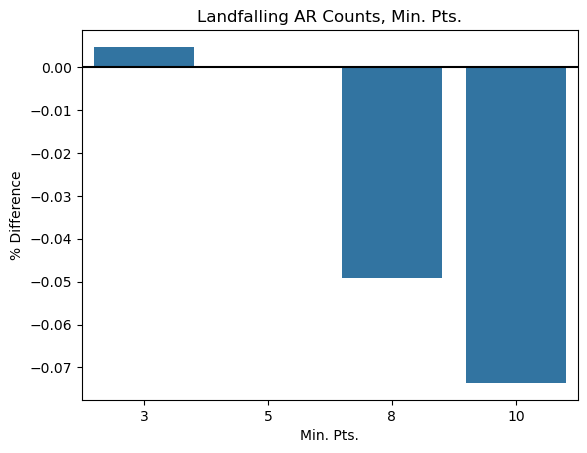

In [17]:
sns.barplot(data=minpts_percents, x=minpts_percents.index, y='landfalling', errorbar=None);
plt.axhline(y=0, linestyle='-', color='black')
plt.title('Landfalling AR Counts, Min. Pts.')
plt.xlabel('Min. Pts.')
plt.ylabel('% Difference');

**Takeaway:** It's unsurprising that the higher the `min_pts` parameter, the less storms you get since you require more points witihn a neighborhood of each other to instantiate a cluster. The differences don't seem that substantial, but 5 intuitively makes sense given the spatiotemporal clustering step works by stitching groups of 10 points from each cluster across time.

## `n_rep_pts` perturbations

After identifying the clusters present within each time step, we sample a random set of representative points from each cluster and then spatiotemporally stitch these together into clusters across time using the ST-DBSCAN algorithm ([Birant 2007](https://doi.org/10.1016/j.datak.2006.01.013)). We also see how varying this hyperparameter changes our clustering results.

In [18]:
reppts_dict = {}
reppts_dict['5'] = load_catalog('epsspace0.5_epstime12_minpts5_nreppts5_seed12345.h5')
reppts_dict['10'] = baseline_df
reppts_dict['15'] = load_catalog('epsspace0.5_epstime12_minpts5_nreppts15_seed12345.h5')

epsspace0.5_epstime12_minpts5_nreppts5_s(…):   0%|          | 0.00/301M [00:00<?, ?B/s]

epsspace0.5_epstime12_minpts5_nreppts15_(…):   0%|          | 0.00/322M [00:00<?, ?B/s]

In [19]:
res_df = process_cts(reppts_dict)
res_df

,total,landfalling
5,8664,3105
10,8714,3179
15,8608,3159


In [20]:
# percent difference, expressed as a percentage of the total number of storms in baseline configuration
rep_pts_percents = (res_df - res_df.loc['10'])/res_df.loc['10']
rep_pts_percents

,total,landfalling
5,-0.005738,-0.023278
10,0.000000,0.000000
15,-0.012164,-0.006291


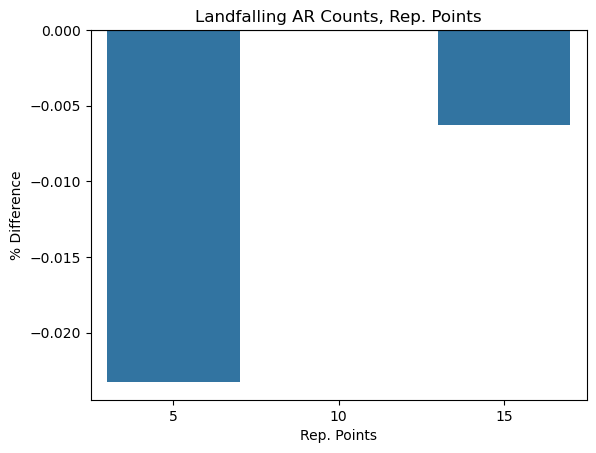

In [21]:
sns.barplot(data=rep_pts_percents, x=rep_pts_percents.index, y='landfalling', errorbar=None)
plt.axhline(y=0, linestyle='-', color='black')
plt.title('Landfalling AR Counts, Rep. Points')
plt.xlabel('Rep. Points')
plt.ylabel('% Difference');

**Takeaway:** results seem fairly stable to perturbations of this parameter.

## seed perturbations

Finally, we perturb the random seed. As there is a stochastic component to this algorithm since we randomly sample representative points from each identified spatial cluster, it is useful to see how sensitive our results are to random sampling.

In [23]:
seed_dict = {}
seed_dict['1111'] = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed1111.h5')
seed_dict['12345'] = baseline_df
seed_dict['2222'] = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed2222.h5')
seed_dict['3333'] = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed3333.h5')
seed_dict['4444'] = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed4444.h5')
seed_dict['5555'] = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed5555.h5')

epsspace0.5_epstime12_minpts5_nreppts10_(…):   0%|          | 0.00/319M [00:00<?, ?B/s]

epsspace0.5_epstime12_minpts5_nreppts10_(…):   0%|          | 0.00/319M [00:00<?, ?B/s]

epsspace0.5_epstime12_minpts5_nreppts10_(…):   0%|          | 0.00/320M [00:00<?, ?B/s]

epsspace0.5_epstime12_minpts5_nreppts10_(…):   0%|          | 0.00/319M [00:00<?, ?B/s]

epsspace0.5_epstime12_minpts5_nreppts10_(…):   0%|          | 0.00/319M [00:00<?, ?B/s]

In [24]:
res_df = process_cts(seed_dict)
res_df

,total,landfalling
1111,8753,3168
12345,8714,3179
2222,8749,3172
3333,8773,3165
4444,8740,3167
5555,8741,3168


In [25]:
# percent difference, expressed as a percentage of the total number of storms in baseline configuration
seed_percents = (res_df - res_df.loc['12345'])/res_df.loc['12345']
seed_percents

,total,landfalling
1111,0.004476,-0.003460
12345,0.000000,0.000000
2222,0.004017,-0.002202
3333,0.006771,-0.004404
4444,0.002984,-0.003775
5555,0.003098,-0.003460


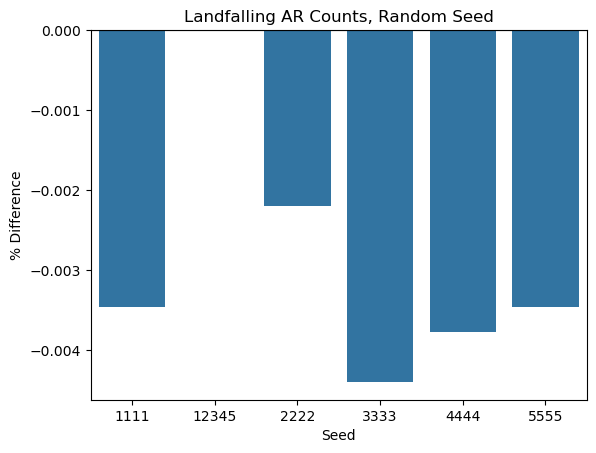

In [26]:
sns.barplot(data=seed_percents, x=seed_percents.index, y='landfalling', errorbar=None)
plt.title('Landfalling AR Counts, Random Seed')
plt.axhline(y=0, linestyle='-', color='black')
plt.xlabel('Seed')
plt.ylabel('% Difference');

**Takeaway:** Results seem very stable to perturbations of the random seed, indicating that the randomness is not introducing too much variability into the numbers of ARs created.

## All Together

We conclude by placing all of the above plots on shared axes so as to compare the sensitivity of our clustering output across the different hyperparameters, isolating which seem to play the most important role.

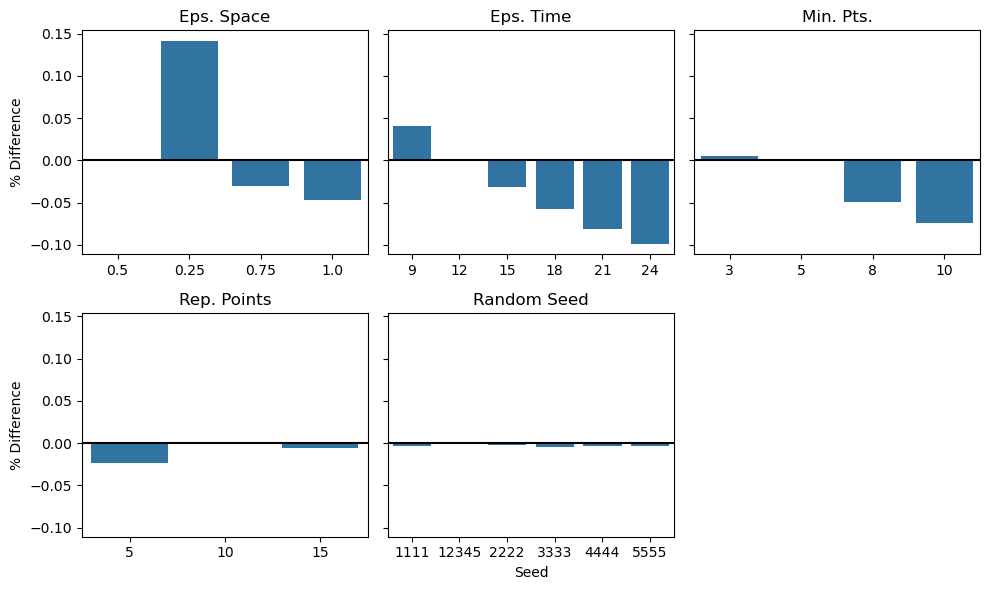

In [27]:
fig, axs = plt.subplots(2, 3, sharey=True)

sns.barplot(data=space_percents, x=space_percents.index, y='landfalling', errorbar=None, ax=axs[0,0])
axs[0,0].axhline(y=0, linestyle='-', color='black')
axs[0,0].set_title('Eps. Space')
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('% Difference');

sns.barplot(data=time_percents, x=time_percents.index, y='landfalling', errorbar=None, ax=axs[0,1])
axs[0,1].axhline(y=0, linestyle='-', color='black')
axs[0,1].set_title('Eps. Time')
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('');

sns.barplot(data=minpts_percents, x=minpts_percents.index, y='landfalling', errorbar=None, ax=axs[0,2])
axs[0,2].axhline(y=0, linestyle='-', color='black')
axs[0,2].set_title('Min. Pts.')
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('');

sns.barplot(data=rep_pts_percents, x=rep_pts_percents.index, y='landfalling', errorbar=None, ax=axs[1,0])
axs[1,0].axhline(y=0, linestyle='-', color='black')
axs[1,0].set_title('Rep. Points')
axs[1,0].set_xlabel('')
axs[1,0].set_ylabel('% Difference');

sns.barplot(data=seed_percents, x=seed_percents.index, y='landfalling', errorbar=None, ax=axs[1,1])
axs[1,1].set_title('Random Seed')
axs[1,1].axhline(y=0, linestyle='-', color='black')
axs[1,1].set_xlabel('Seed')
axs[1,1].set_ylabel('');

axs[1,2].set_axis_off()


fig.set_size_inches((10,6))
plt.tight_layout()